In [123]:
# Library imports
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import plotly.graph_objects as go

import warnings
from astropy.utils.exceptions import ErfaWarning
# Ignore ERFA dubious year warnings
warnings.filterwarnings('ignore', category=ErfaWarning, append=True)

from erfa import ErfaWarning

 [astropy.utils.exceptions]


# <span style="color:pink">Proyecto Apophis M. Cel 2026</span>

### Marhia José Granada Restrepo
#### 1094890344
#### Universidad de Antioquia

## <span style="color:purple">**Introducción**</span>


Apophis (99942) es un asteroide con una órbita próxima a la de la tierra que originalmente presentaba una probabilidad de impacto contra ella, sin embargo, después de observaciones de un acercamiento en 2013, la NASA descartó la posibiidad de un impacto en 2036, y con observaciones del 2021, se descartó el impacto para el año 2029, pero aún así este año se presentará un acercamiento a la tierra de una distancia menor a 36000km, que es la distancia a la que se encuentran la mayoría de los satélite estacionarios que tenemos.

Así, el análisis de este evento es un excelente escenario de práctica para la mecánica celeste. Permite hacer un análisis de un caso real donde un cuerpo se ve afectado por las fuerzas de atracción que genera la tierra sobre él, y altera su trayectoria, velocidad y energía.

Durante el desarrollo de este proyecto se propone entonces: 

- Replicar la trayectoria del cuerpo mediante diferentes aproximaciones.
- Analizar la trayectoría y el cambio de esta debido a la influencia de la tierra.
- Confirmar la distancia de acercamiento a la tierra 
- Analizar qué cambios se deberían presentar para que ocurra un impacto.

## <span style="color:purple">**Sistema de Unidades Canónicas**</span>

Para garantizar la estabilidad numérica durante la integración de las ecuaciones de movimiento, se hace necesario adaptar las medidas a un sistema que no presente tantas diferencias entre los órdenes de magnitud de las características físicas de los cuerpos.

Elegimos así las siguientes unidades de medición para la masa, la distancia y para el parámetro gravitacional G:
* Unidad de Masa (MU): $1 \, M_{\odot}$ (Masa Solar)
* Unidad de Distancia (DU): $1 \, \text{AU}$ (Unidad Astronómica)
* Constante de gravitación (G): $1 \ $

Ahora, para que la ecuación de movimiento $\ddot{\mathbf{r}} = -G \frac{M}{r^3} \mathbf{r}$ siga siendo válida, debemos de realizar el siguiente cambio para el valor del paso temporal (TU) 

$$TU = \sqrt{\frac{DU^3}{G \cdot MU}}$$

Sustituyendo los valores:

$$TU = \sqrt{\frac{(1.495978707 \times 10^{11} \, \text{m})^3}{(6.67430 \times 10^{-11} \, \text{m}^3 \text{kg}^{-1} \text{s}^{-2}) (1.98847 \times 10^{30} \, \text{kg})}} \approx 5.022 \times 10^6 \, \text{s}$$

Que equivale aproximadamente a **58.132 días**. 

Por lo tanto, la unidad de velocidad canónica ($VU$) se define como:

$$VU = \frac{DU}{TU} \approx 29.78 \, \text{km/s}$$

In [124]:
# Entonces, el sistema de unidades:

G = pc.constantes.G
MU = pc.constantes.M_sun # en kg
AU = pc.constantes.au # en metros !!

T_canon = np.sqrt(AU**3/(G*MU)) # Time unit
V_canon = AU/T_canon # Velocity unit

## <span style="color:purple">**Experimento 1: Sensibilidad del Modelo N-Cuerpos**</span>


Para comenzar el análisis de esta aproximación, se construyen una serie de modelos con el fin de compararlos, se comienza por uno básico, de 4 cuerpos (Sol, Tierra, Luna, Apophis), luego uno de 11 cuerpos, que incluye a todos los planetas del sistema solar y a la luna, y finalmente un modelo de 17 cuerpos, donde se incluyen todos los planetas, la luna y los asteroides Ceres, Pallas, Vesta, Hygiea e Interamnia. Se integra durante 6 Unidades de Tiempo canónico (poco menos de un año), partiendo de la fecha de Enero 1 del año 2029, con un número de pasos de 1500, así se tiene una "foto" del sistema cada aproximadamente 5.5 horas.

In [125]:
# we first get the initial conditions for allbodies and convert them to canonical units. 
# we also get the masses of the bodies and convert them to canonical mass units.

# Apophis
tabla_apophis, jd_apophis, pos_vel_apophis = pc.consulta_horizons(id = "99942", location = "@0", epochs = "2029-01-01")
pos_vel_apophis = pos_vel_apophis / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert a unidades canónicas de posición y velocidad
mass_apophis = 18143694800 # masa estimada de apophis en kg, tomada de https://www.esa.int/Space_Safety/Planetary_Defence/Apophis
masa_apophis = mass_apophis / MU # Conversión a unidades canónicas de masa

# Tierra

tabla_tierra, jd_tierra, pos_vel_tierra = pc.consulta_horizons(id = "399", location = "@0", epochs = "2029-01-01")
pos_vel_tierra = pos_vel_tierra / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_tierra = pc.constantes.M_earth / MU # Convert to canonical mass units
radio_tierra = pc.constantes.R_earth / AU # Convert to canonical distance units

# Luna

tabla_luna, jd_luna, pos_vel_luna = pc.consulta_horizons(id = "301", location = "@0", epochs = "2029-01-01")
pos_vel_luna = pos_vel_luna / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_luna = (pc.constantes.mu_moon)/G / MU # Convert to canonical mass units

In [126]:
# Planetasss

# Internos

tabla_mercurio, jd_mercurio, pos_vel_mercurio = pc.consulta_horizons(id = "199", location = "@0", epochs = "2029-01-01")
pos_vel_mercurio = pos_vel_mercurio / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_mercurio = (pc.constantes.mu_mercury)/G / MU # Convert to canonical mass units

tabla_venus, jd_venus, pos_vel_venus = pc.consulta_horizons(id = "299", location = "@0", epochs = "2029-01-01")
pos_vel_venus = pos_vel_venus / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_venus = (pc.constantes.mu_venus)/G / MU # Convert to canonical mass units

# Externos

tabla_marte, jd_marte, pos_vel_marte = pc.consulta_horizons(id = "499", location = "@0", epochs = "2029-01-01")
pos_vel_marte = pos_vel_marte / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_marte = (pc.constantes.mu_mars)/G / MU # Convert to canonical mass units

tabla_jupiter, jd_jupiter, pos_vel_jupiter = pc.consulta_horizons(id = "599", location = "@0", epochs = "2029-01-01")
pos_vel_jupiter = pos_vel_jupiter / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_jupiter = pc.constantes.M_jup / MU # Convert to canonical mass units

tabla_saturno, jd_saturno, pos_vel_saturno = pc.consulta_horizons(id = "699", location = "@0", epochs = "2029-01-01")
pos_vel_saturno = pos_vel_saturno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_saturno = (pc.constantes.mu_saturn)/G / MU # Convert to canonical mass units

tabla_urano, jd_urano, pos_vel_urano = pc.consulta_horizons(id = "799", location = "@0", epochs = "2029-01-01")
pos_vel_urano = pos_vel_urano / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_urano = (pc.constantes.mu_uranus)/G / MU # Convert to canonical mass units

tabla_neptuno, jd_neptuno, pos_vel_neptuno = pc.consulta_horizons(id = "899", location = "@0", epochs = "2029-01-01")
pos_vel_neptuno = pos_vel_neptuno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_neptuno = (pc.constantes.mu_neptune)/G / MU # Convert to canonical mass units

In [127]:
tabla_ceres, jd_ceres, pos_ceres = pc.consulta_horizons(id = "ceres", location = "@0", epochs = "2029-01-01")
mass_ceres = 9.393e20 # kg, estimated mass of Ceres
mass_ceres_canon = mass_ceres / MU # Convert to canonical mass units
pos_vel_ceres = pos_ceres / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_pallas, jd_pallas, pos_pallas = pc.consulta_horizons(id = "pallas", location = "@0", epochs = "2029-01-01")
mass_pallas = 2.14e20 # kg, estimated mass of Pallas
mass_pallas_canon = mass_pallas / MU
pos_vel_pallas = pos_pallas / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_vesta, jd_vesta, pos_vesta = pc.consulta_horizons(id = "vesta", location = "@0", epochs = "2029-01-01")
mass_vesta = 2.59e20 # kg, estimated mass of Vesta
mass_vesta_canon = mass_vesta / MU
pos_vel_vesta = pos_vesta / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_Hygiea, jd_hygiea, pos_hygiea = pc.consulta_horizons(id = "hygiea", location = "@0", epochs = "2029-01-01")
mass_hygiea = 8.32e19 # kg, estimated mass of Hygiea
mass_hygiea_canon = mass_hygiea / MU
pos_vel_hygiea = pos_hygiea / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_interamnia, jd_interamnia, pos_interamnia = pc.consulta_horizons(id = "interamnia", location = "@0", epochs = "2029-01-01")
mass_interamnia = 3.9e19 # kg, estimated mass of Interamnia
mass_interamnia_canon = mass_interamnia / MU
pos_vel_interamnia = pos_interamnia / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

### <span style="color:pink">Modelo de 4 cuerpos</span>

Para establecer un punto de control, el primer experimento evalúa un sistema dinámico compuesto por cuatro masas fundamentales: el Sol, la Tierra, la Luna y (99942) Apophis. 

In [128]:
# Rebound simulation

steps = 1500
ts = np.linspace(0, 6, steps)

cuerpos = 4 
sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.add(m=masa_luna, x=pos_vel_luna[0], y=pos_vel_luna[1], z=pos_vel_luna[2], vx=pos_vel_luna[3], vy=pos_vel_luna[4], vz=pos_vel_luna[5]) # Luna
sim.move_to_com()

# Integrate

rps = np.zeros((cuerpos, steps, 3))
vps = np.zeros((cuerpos, steps, 3))
rs = np.zeros((cuerpos, steps, 3))
vs = np.zeros((cuerpos, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(cuerpos):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [129]:
# Gráfica 3d para el sistema Sol-Tierra-Luna-Apophis

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rs[0, :, 0], y=rs[0, :, 1], z=rs[0, :, 2], mode='lines', name='Sol'))
fig.add_trace(go.Scatter3d(x=rs[1, :, 0], y=rs[1, :, 1], z=rs[1, :, 2], mode='lines', name='Apophis'))
fig.add_trace(go.Scatter3d(x=rs[2, :, 0], y=rs[2, :, 1], z=rs[2, :, 2], mode='lines', name='Tierra'))
fig.add_trace(go.Scatter3d(x=rs[3, :, 0], y=rs[3, :, 1], z=rs[3, :, 2], mode='lines', name='Luna'))

# Agregar posiciones iniciales
for i in range(cuerpos):
    fig.add_trace(go.Scatter3d(x=[rs[i, 0, 0]], y=[rs[i, 0, 1]], z=[rs[i, 0, 2]], mode='markers', name=f'{["Sol", "Apophis", "Tierra", "Luna"][i]} inicial'))

fig.update_layout(title='Trayectorias de Sol, Tierra, Luna y Apophis', scene=dict(xaxis_title='X (AU)', yaxis_title='Y (AU)', zaxis_title='Z (AU)'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

In [130]:
# We get the distance between Apophis and the Earth at each time step, and find the minimum distance.
distancias_4cuerpos = np.linalg.norm((rs[1] - rs[2]), axis=1) - radio_tierra # we substract the Earth's radius to get the distance from Apophis to the surface of the Earth.
distancia_minima_4cuerpos = np.min(distancias_4cuerpos)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima_4cuerpos * AU / 1000} km")

# Date for minimum distance
indice_minimo = np.argmin(distancias_4cuerpos)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) # Convertir tiempo canónico a días

fecha_minima_fecha = np.datetime64('2029-01-01') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

Distancia mínima entre Apophis y la Tierra: 243823.01107385036 km
Fecha de la distancia mínima: 2029-04-13


### <span style="color:pink">Modelo de 11 cuerpos</span>

Para escalar la complejidad del sistema, este segundo modelo incorpora a los siete planetas restantes del sistema solar, con el fin de evaluar si sus perturbaciones a larga distancia alteran la geometría del encuentro.

In [131]:
# 11 body system

cuerpos = 11
sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.add(m=masa_luna, x=pos_vel_luna[0], y=pos_vel_luna[1], z=pos_vel_luna[2], vx=pos_vel_luna[3], vy=pos_vel_luna[4], vz=pos_vel_luna[5]) # Luna
sim.add(m=masa_mercurio, x=pos_vel_mercurio[0], y=pos_vel_mercurio[1], z=pos_vel_mercurio[2], vx=pos_vel_mercurio[3], vy=pos_vel_mercurio[4], vz=pos_vel_mercurio[5]) # Mercurio
sim.add(m=masa_venus, x=pos_vel_venus[0], y=pos_vel_venus[1], z=pos_vel_venus[2], vx=pos_vel_venus[3], vy=pos_vel_venus[4], vz=pos_vel_venus[5]) # Venus
sim.add(m=masa_marte, x=pos_vel_marte[0], y=pos_vel_marte[1], z=pos_vel_marte[2], vx=pos_vel_marte[3], vy=pos_vel_marte[4], vz=pos_vel_marte[5]) # Marte
sim.add(m=masa_jupiter, x=pos_vel_jupiter[0], y=pos_vel_jupiter[1], z=pos_vel_jupiter[2], vx=pos_vel_jupiter[3], vy=pos_vel_jupiter[4], vz=pos_vel_jupiter[5]) # Jupiter
sim.add(m=masa_saturno, x=pos_vel_saturno[0], y=pos_vel_saturno[1], z=pos_vel_saturno[2], vx=pos_vel_saturno[3], vy=pos_vel_saturno[4], vz=pos_vel_saturno[5]) # Saturno
sim.add(m=masa_urano, x=pos_vel_urano[0], y=pos_vel_urano[1], z=pos_vel_urano[2], vx=pos_vel_urano[3], vy=pos_vel_urano[4], vz=pos_vel_urano[5]) # Urano
sim.add(m=masa_neptuno, x=pos_vel_neptuno[0], y=pos_vel_neptuno[1], z=pos_vel_neptuno[2], vx=pos_vel_neptuno[3], vy=pos_vel_neptuno[4], vz=pos_vel_neptuno[5]) # Neptuno
sim.move_to_com()
sim.move_to_com()

# Integrate

rps = np.zeros((cuerpos, steps, 3))
vps = np.zeros((cuerpos, steps, 3))
rs = np.zeros((cuerpos, steps, 3))
vs = np.zeros((cuerpos, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(cuerpos):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [132]:
# Gráfica 3d para el sistema Solar

fig = go.Figure()

for i in range(cuerpos):
    fig.add_trace(go.Scatter3d(x=rs[i, :, 0], y=rs[i, :, 1], z=rs[i, :, 2], mode='lines', name=f'{["Sol", "Apophis", "Tierra", "Luna", "Mercurio", "Venus", "Marte", "Jupiter", "Saturno", "Urano", "Neptuno"][i]}'))

# initial positions
for i in range(cuerpos):
    fig.add_trace(go.Scatter3d(x=[rs[i, 0, 0]], y=[rs[i, 0, 1]], z=[rs[i, 0, 2]], mode='markers', name=f'{["Sol", "Apophis", "Tierra", "Luna", "Mercurio", "Venus", "Marte", "Jupiter", "Saturno", "Urano", "Neptuno"][i]} inicial'))

fig.update_layout(title='Trayectorias del sistema solar', scene=dict(xaxis_title='X (AU)', yaxis_title='Y (AU)', zaxis_title='Z (AU)'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

In [133]:
distancias_solar = np.linalg.norm((rs[1] - rs[2]), axis=1) - radio_tierra
distancia_minima_solar = np.min(distancias_solar)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima_solar * AU / 1000} km")

indice_minimo = np.argmin(distancias_solar)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) # Convertir tiempo canónico a días

fecha_minima_fecha = np.datetime64('2029-01-01') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

Distancia mínima entre Apophis y la Tierra: 244669.68690120414 km
Fecha de la distancia mínima: 2029-04-13


### <span style="color:pink">Modelo de 16 cuerpos</span>

Finalmente, se incluyen cinco cuerpos del cinturón principal de asteroides (Ceres, Pallas, Vesta, Hygiea e Interamnia) para llevar la simulación al máximo nivel de fidelidad gravitacional propuesto en este análisis, completando un sistema de 16 partículas.

In [134]:
# 16 body system

cuerpos = 16
sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.add(m=masa_luna, x=pos_vel_luna[0], y=pos_vel_luna[1], z=pos_vel_luna[2], vx=pos_vel_luna[3], vy=pos_vel_luna[4], vz=pos_vel_luna[5]) # Luna
sim.add(m=masa_mercurio, x=pos_vel_mercurio[0], y=pos_vel_mercurio[1], z=pos_vel_mercurio[2], vx=pos_vel_mercurio[3], vy=pos_vel_mercurio[4], vz=pos_vel_mercurio[5]) # Mercurio
sim.add(m=masa_venus, x=pos_vel_venus[0], y=pos_vel_venus[1], z=pos_vel_venus[2], vx=pos_vel_venus[3], vy=pos_vel_venus[4], vz=pos_vel_venus[5]) # Venus
sim.add(m=masa_marte, x=pos_vel_marte[0], y=pos_vel_marte[1], z=pos_vel_marte[2], vx=pos_vel_marte[3], vy=pos_vel_marte[4], vz=pos_vel_marte[5]) # Marte
sim.add(m=masa_jupiter, x=pos_vel_jupiter[0], y=pos_vel_jupiter[1], z=pos_vel_jupiter[2], vx=pos_vel_jupiter[3], vy=pos_vel_jupiter[4], vz=pos_vel_jupiter[5]) # Jupiter
sim.add(m=masa_saturno, x=pos_vel_saturno[0], y=pos_vel_saturno[1], z=pos_vel_saturno[2], vx=pos_vel_saturno[3], vy=pos_vel_saturno[4], vz=pos_vel_saturno[5]) # Saturno
sim.add(m=masa_urano, x=pos_vel_urano[0], y=pos_vel_urano[1], z=pos_vel_urano[2], vx=pos_vel_urano[3], vy=pos_vel_urano[4], vz=pos_vel_urano[5]) # Urano
sim.add(m=masa_neptuno, x=pos_vel_neptuno[0], y=pos_vel_neptuno[1], z=pos_vel_neptuno[2], vx=pos_vel_neptuno[3], vy=pos_vel_neptuno[4], vz=pos_vel_neptuno[5]) # Neptuno
sim.add(m=mass_ceres_canon, x=pos_vel_ceres[0], y=pos_vel_ceres[1], z=pos_vel_ceres[2], vx=pos_vel_ceres[3], vy=pos_vel_ceres[4], vz=pos_vel_ceres[5]) # Ceres
sim.add(m=mass_pallas_canon, x=pos_vel_pallas[0], y=pos_vel_pallas[1], z=pos_vel_pallas[2], vx=pos_vel_pallas[3], vy=pos_vel_pallas[4], vz=pos_vel_pallas[5]) # Pallas
sim.add(m=mass_vesta_canon, x=pos_vel_vesta[0], y=pos_vel_vesta[1], z=pos_vel_vesta[2], vx=pos_vel_vesta[3], vy=pos_vel_vesta[4], vz=pos_vel_vesta[5]) # Vesta
sim.add(m=mass_hygiea_canon, x=pos_vel_hygiea[0], y=pos_vel_hygiea[1], z=pos_vel_hygiea[2], vx=pos_vel_hygiea[3], vy=pos_vel_hygiea[4], vz=pos_vel_hygiea[5]) # Hygiea
sim.add(m=mass_interamnia_canon, x=pos_vel_interamnia[0], y=pos_vel_interamnia[1], z=pos_vel_interamnia[2], vx=pos_vel_interamnia[3], vy=pos_vel_interamnia[4], vz=pos_vel_interamnia[5]) # Interamnia
sim.move_to_com()

# Integrate

rps = np.zeros((cuerpos, steps, 3))
vps = np.zeros((cuerpos, steps, 3))
rs = np.zeros((cuerpos, steps, 3))
vs = np.zeros((cuerpos, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(cuerpos):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [135]:
# Gráfica 3d para el sistema Solar

fig = go.Figure()

for i in range(cuerpos):
    fig.add_trace(go.Scatter3d(x=rs[i, :, 0], y=rs[i, :, 1], z=rs[i, :, 2], mode='lines', name=f'{["Sol", "Apophis", "Tierra", "Luna", "Mercurio", "Venus", "Marte", "Jupiter", "Saturno", "Urano", "Neptuno", "Ceres", "Pallas", "Vesta", "Hygiea", "Interamnia"][i]}'))

# Initial positions
for i in range(cuerpos):
    fig.add_trace(go.Scatter3d(x=[rs[i, 0, 0]], y=[rs[i, 0, 1]], z=[rs[i, 0, 2]], mode='markers', name=f'{["Sol", "Apophis", "Tierra", "Luna", "Mercurio", "Venus", "Marte", "Jupiter", "Saturno", "Urano", "Neptuno", "Ceres", "Pallas", "Vesta", "Hygiea", "Interamnia"][i]} inicial'))

fig.update_layout(title='Trayectorias del sistema solar', scene=dict(xaxis_title='X (AU)', yaxis_title='Y (AU)', zaxis_title='Z (AU)'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

In [136]:
distancias_completo = np.linalg.norm((rs[1] - rs[2]), axis=1) - radio_tierra
distancia_minima_completo = np.min(distancias_completo)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima_completo * AU / 1000} km")

# min distance date
indice_minimo = np.argmin(distancias_completo)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) # Convertir tiempo canónico a días
fecha_minima_fecha = np.datetime64('2029-01-01') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

Distancia mínima entre Apophis y la Tierra: 244669.68487775122 km
Fecha de la distancia mínima: 2029-04-13


### <span style="color:pink">Resultados</span>

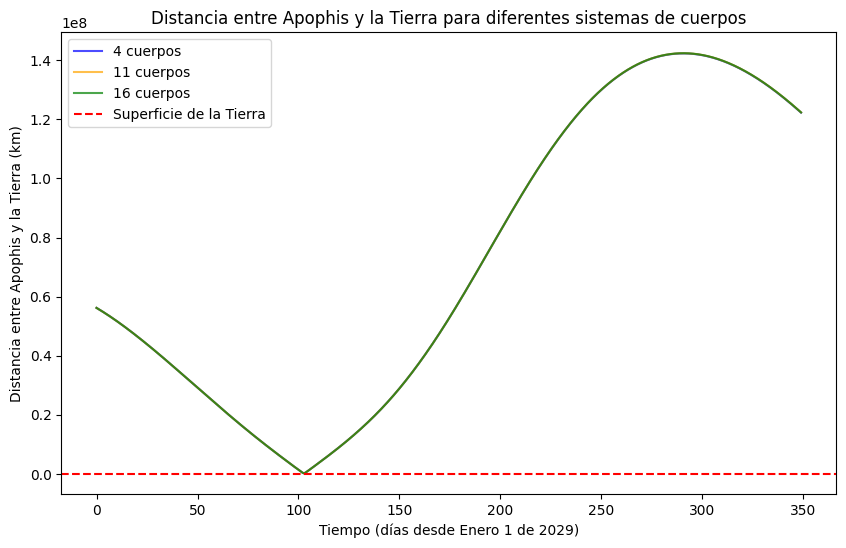

In [137]:
# we now compare the results of the three simulations by plotting the distance between Apophis and the Earth as a function of time for each simulation

plt.figure(figsize=(10, 6))
plt.plot(ts * T_canon / (24 * 3600), distancias_4cuerpos * AU / 1000, label='4 cuerpos', color='blue', alpha=0.7)
plt.plot(ts * T_canon / (24 * 3600), distancias_solar * AU / 1000, label='11 cuerpos', color='orange', alpha=0.7)
plt.plot(ts * T_canon / (24 * 3600), distancias_completo * AU / 1000, label='16 cuerpos', color='green', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', label='Superficie de la Tierra')
plt.xlabel('Tiempo (días desde Enero 1 de 2029)')
plt.ylabel('Distancia entre Apophis y la Tierra (km)')
plt.title('Distancia entre Apophis y la Tierra para diferentes sistemas de cuerpos')
plt.legend()
plt.show()

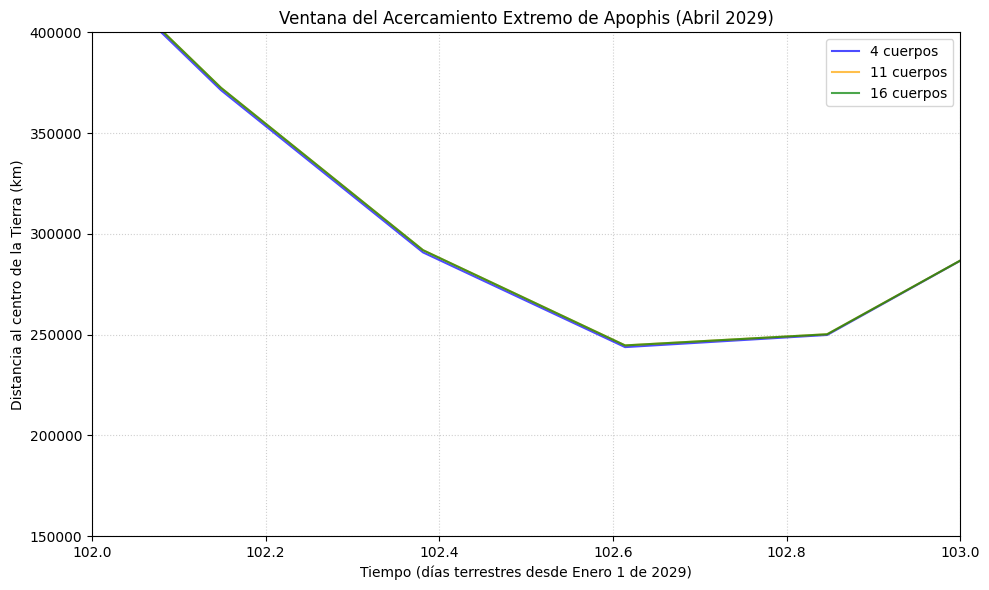

In [138]:
# we now focus on th eperiod around the closest approach, which is around April 13, 2029.

plt.figure(figsize=(10, 6))

tiempo_dias = ts * T_canon / (24 * 3600)

plt.plot(tiempo_dias, distancias_4cuerpos * AU / 1000, label='4 cuerpos', color='blue', alpha=0.7)
plt.plot(tiempo_dias, distancias_solar * AU / 1000, label='11 cuerpos', color='orange', alpha=0.7)
plt.plot(tiempo_dias, distancias_completo * AU / 1000, label='16 cuerpos', color='green', alpha=0.7)

plt.xlim(102, 103)
plt.xlabel('Tiempo (días terrestres desde Enero 1 de 2029)')
plt.ylabel('Distancia al centro de la Tierra (km)')
plt.title('Ventana del Acercamiento Extremo de Apophis (Abril 2029)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(150000, 400000)
plt.tight_layout()
plt.show()

In [139]:
# Differences for the simulations

# 4 body vs complete
diferencia_4_completo = np.abs(distancia_minima_4cuerpos - distancia_minima_completo) * AU / 1000
print(f"Diferencia en la distancia mínima entre la simulación de 4 cuerpos y la de 16 cuerpos: {diferencia_4_completo} km")

# 11 body vs complete
diferencia_11_completo = np.abs(distancia_minima_solar - distancia_minima_completo) * AU / 1000
print(f"Diferencia en la distancia mínima entre la simulación de 11 cuerpos y la de 16 cuerpos: {diferencia_11_completo} km")

Diferencia en la distancia mínima entre la simulación de 4 cuerpos y la de 16 cuerpos: 846.6738039008594 km
Diferencia en la distancia mínima entre la simulación de 11 cuerpos y la de 16 cuerpos: 0.0020234529136780744 km


Al graficar la evolución temporal de la distancia relativa, las trayectorias de los tres escenarios parecen idénticas a escala macroscópica. Sin embargo, al limitar la ventana de observación a los días de la máxima aproximación (alrededor del día 102 desde el inicio de la simulación), se puede ver una muy sutil diferencia entre el modelo de 4 cuerpos y los modelos de 11 y 16 cuerpos, cyas distancias sí son casi indistinguibles.

El cálculo de los residuales de distancia demuestra el peso de la jerarquía gravitacional. Al comparar el sistema base con el sistema completo, se observa que la influencia acumulada de los demás planetas altera la trayectoria del asteroide en al menos 846.67 km. En contraste, la adición de los cinco asteroides (Ceres, Pallas, Vesta, Hygiea e Interamnia) apenas introduce una desviación de 0.002 km.

Finalmente, la gráfica y los cálculos exponen un límite numérico del integrador. La distancia mínima registrada converge cerca de los 243000 km, un valor drásticamente superior al acercamiento real esperado ($\sim 32,000$ km). Esta grand distancia es consecuencia directa del paso de integración ($\Delta t$). Al discretizar casi un año en 1500 pasos, el tiempo entre evaluaciones es demasiado amplio ($\approx 5.5$ horas). Debido a la velocidad del asteroide en el perigeo, la simulación captura posiciones antes y después del encuentro extremo, omitiendo el vértice exacto de la trayectoria.

## <span style="color:purple">**Experimento 2: Dinámica de la Máxima Aproximación**</span>

### <span style="color:pink">Máxima aproximación de Apophis</span>

Para mitigar el error de discretización temporal, se reconstruye el modelo de 16 cuerpos inicializando el modelo en el 10 de abril de 2029. El horizonte de integración se reduce a $0.12 \, \text{TU}$ (aproximadamente 7 días) con una partición de 3500 pasos, estableciendo un $\Delta t$ del orden de minutos. Esta configuración garantiza la resolución matemática necesaria para capturar el instante de la máxima aproximación.

In [140]:
# we get all the data from Horizons again, but with the epoch of April 10, 2029, which is closer to the date of the closest approach.
# commit: I accidentaly got all masses twice, soooo

# Apophis
tabla_apophis, jd_apophis, pos_vel_apophis = pc.consulta_horizons(id = "99942", location = "@0", epochs = "2029-04-10")
pos_vel_apophis = pos_vel_apophis / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

# Tierra

tabla_tierra, jd_tierra, pos_vel_tierra = pc.consulta_horizons(id = "399", location = "@0", epochs = "2029-04-10")
pos_vel_tierra = pos_vel_tierra / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

# Luna

tabla_luna, jd_luna, pos_vel_luna = pc.consulta_horizons(id = "301", location = "@0", epochs = "2029-04-10")
pos_vel_luna = pos_vel_luna / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

# planetas

# Internos

tabla_mercurio, jd_mercurio, pos_vel_mercurio = pc.consulta_horizons(id = "199", location = "@0", epochs = "2029-04-10")
pos_vel_mercurio = pos_vel_mercurio / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_venus, jd_venus, pos_vel_venus = pc.consulta_horizons(id = "299", location = "@0", epochs = "2029-04-10")
pos_vel_venus = pos_vel_venus / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

# Externos

tabla_marte, jd_marte, pos_vel_marte = pc.consulta_horizons(id = "499", location = "@0", epochs = "2029-04-10")
pos_vel_marte = pos_vel_marte / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_jupiter, jd_jupiter, pos_vel_jupiter = pc.consulta_horizons(id = "599", location = "@0", epochs = "2029-04-10")
pos_vel_jupiter = pos_vel_jupiter / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_saturno, jd_saturno, pos_vel_saturno = pc.consulta_horizons(id = "699", location = "@0", epochs = "2029-04-10")
pos_vel_saturno = pos_vel_saturno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_urano, jd_urano, pos_vel_urano = pc.consulta_horizons(id = "799", location = "@0", epochs = "2029-04-10")
pos_vel_urano = pos_vel_urano / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_neptuno, jd_neptuno, pos_vel_neptuno = pc.consulta_horizons(id = "899", location = "@0", epochs = "2029-04-10")
pos_vel_neptuno = pos_vel_neptuno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

# Now we also add the next 5 most massive asteroids (Ceres, Pallas, Vesta, Hygiea, Interamnia)

tabla_ceres, jd_ceres, pos_ceres = pc.consulta_horizons(id = "ceres", location = "@0", epochs = "2029-04-10")
pos_vel_ceres = pos_ceres / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_pallas, jd_pallas, pos_pallas = pc.consulta_horizons(id = "pallas", location = "@0", epochs = "2029-04-10")
pos_vel_pallas = pos_pallas / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_vesta, jd_vesta, pos_vesta = pc.consulta_horizons(id = "vesta", location = "@0", epochs = "2029-04-10")
pos_vel_vesta = pos_vesta / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_Hygiea, jd_hygiea, pos_hygiea = pc.consulta_horizons(id = "hygiea", location = "@0", epochs = "2029-04-10")
pos_vel_hygiea = pos_hygiea / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_interamnia, jd_interamnia, pos_interamnia = pc.consulta_horizons(id = "interamnia", location = "@0", epochs = "2029-04-10")
pos_vel_interamnia = pos_interamnia / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

In [141]:
# Sistema de 16 cuerpos

cuerpos = 16 
steps = 4000 # we increase the number of steps to get a better resolution !! 
ts = np.linspace(0, 0.12, steps) # we just check for 3 days prior and 3 days after the closest approach.

sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.add(m=masa_luna, x=pos_vel_luna[0], y=pos_vel_luna[1], z=pos_vel_luna[2], vx=pos_vel_luna[3], vy=pos_vel_luna[4], vz=pos_vel_luna[5]) # Luna
sim.add(m=masa_mercurio, x=pos_vel_mercurio[0], y=pos_vel_mercurio[1], z=pos_vel_mercurio[2], vx=pos_vel_mercurio[3], vy=pos_vel_mercurio[4], vz=pos_vel_mercurio[5]) # Mercurio
sim.add(m=masa_venus, x=pos_vel_venus[0], y=pos_vel_venus[1], z=pos_vel_venus[2], vx=pos_vel_venus[3], vy=pos_vel_venus[4], vz=pos_vel_venus[5]) # Venus
sim.add(m=masa_marte, x=pos_vel_marte[0], y=pos_vel_marte[1], z=pos_vel_marte[2], vx=pos_vel_marte[3], vy=pos_vel_marte[4], vz=pos_vel_marte[5]) # Marte
sim.add(m=masa_jupiter, x=pos_vel_jupiter[0], y=pos_vel_jupiter[1], z=pos_vel_jupiter[2], vx=pos_vel_jupiter[3], vy=pos_vel_jupiter[4], vz=pos_vel_jupiter[5]) # Jupiter
sim.add(m=masa_saturno, x=pos_vel_saturno[0], y=pos_vel_saturno[1], z=pos_vel_saturno[2], vx=pos_vel_saturno[3], vy=pos_vel_saturno[4], vz=pos_vel_saturno[5]) # Saturno
sim.add(m=masa_urano, x=pos_vel_urano[0], y=pos_vel_urano[1], z=pos_vel_urano[2], vx=pos_vel_urano[3], vy=pos_vel_urano[4], vz=pos_vel_urano[5]) # Urano
sim.add(m=masa_neptuno, x=pos_vel_neptuno[0], y=pos_vel_neptuno[1], z=pos_vel_neptuno[2], vx=pos_vel_neptuno[3], vy=pos_vel_neptuno[4], vz=pos_vel_neptuno[5]) # Neptuno
sim.add(m=mass_ceres_canon, x=pos_vel_ceres[0], y=pos_vel_ceres[1], z=pos_vel_ceres[2], vx=pos_vel_ceres[3], vy=pos_vel_ceres[4], vz=pos_vel_ceres[5]) # Ceres
sim.add(m=mass_pallas_canon, x=pos_vel_pallas[0], y=pos_vel_pallas[1], z=pos_vel_pallas[2], vx=pos_vel_pallas[3], vy=pos_vel_pallas[4], vz=pos_vel_pallas[5]) # Pallas
sim.add(m=mass_vesta_canon, x=pos_vel_vesta[0], y=pos_vel_vesta[1], z=pos_vel_vesta[2], vx=pos_vel_vesta[3], vy=pos_vel_vesta[4], vz=pos_vel_vesta[5]) # Vesta
sim.add(m=mass_hygiea_canon, x=pos_vel_hygiea[0], y=pos_vel_hygiea[1], z=pos_vel_hygiea[2], vx=pos_vel_hygiea[3], vy=pos_vel_hygiea[4], vz=pos_vel_hygiea[5]) # Hygiea
sim.add(m=mass_interamnia_canon, x=pos_vel_interamnia[0], y=pos_vel_interamnia[1], z=pos_vel_interamnia[2], vx=pos_vel_interamnia[3], vy=pos_vel_interamnia[4], vz=pos_vel_interamnia[5]) # Interamnia
sim.move_to_com()

# Integrate

rps = np.zeros((cuerpos, steps, 3))
vps = np.zeros((cuerpos, steps, 3))
rs = np.zeros((cuerpos, steps, 3))
vs = np.zeros((cuerpos, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(cuerpos):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [142]:
distancias_completo = np.linalg.norm((rs[1] - rs[2]), axis=1) - radio_tierra
distancia_minima = np.min(distancias_completo)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima * AU / 1000} km")

# we get the date of min distance
indice_minimo = np.argmin(distancias_completo)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) 
fecha_minima_fecha = np.datetime64('2029-04-10') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

# we get the exact time of the closest approach in hours and minutes
fecha_minima_hora = fecha_minima - int(fecha_minima) 
fecha_minima_hora = fecha_minima_hora * 24 
minutos = (fecha_minima_hora - int(fecha_minima_hora)) * 60 
print(f"Hora del día de la distancia mínima: {int(fecha_minima_hora)}:{int(minutos)}")
segundos = (minutos - int(minutos)) * 60
print(f"Minutos del día de la distancia mínima: {int(fecha_minima_hora)}:{int(minutos)}:{int(segundos)}")

Distancia mínima entre Apophis y la Tierra: 31632.737931175696 km
Fecha de la distancia mínima: 2029-04-13
Hora del día de la distancia mínima: 21:46
Minutos del día de la distancia mínima: 21:46:46


In [143]:
# Difference with NASA's data (from JPL's small body database)
dist_nasa_km = 38011
dist_nasa_km = dist_nasa_km - (pc.constantes.R_earth/1000)
diferencia_nasa = np.abs(dist_nasa_km - (distancia_minima * AU / 1000))
print(f"Diferencia entre la distancia mínima calculada y la distancia de la NASA: {diferencia_nasa} km")

from astropy.time import Time
fecha_nasa_JD = 2462240.407091969
fecha_nasa = Time(fecha_nasa_JD, format='jd').datetime
print(f"Fecha de la distancia mínima según la NASA: {fecha_nasa}")

Diferencia entre la distancia mínima calculada y la distancia de la NASA: 0.16206882430560654 km
Fecha de la distancia mínima según la NASA: 2029-04-13 21:46:12.746135


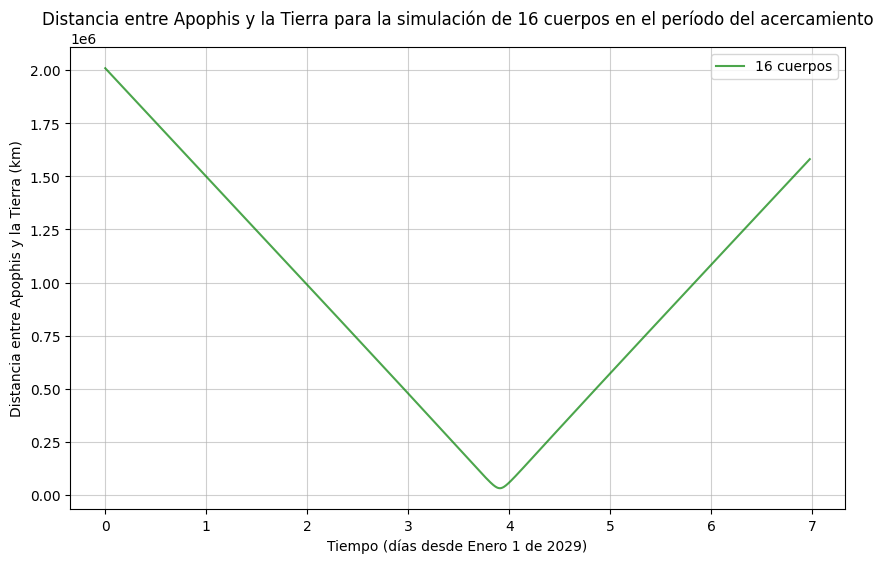

In [144]:
# gráfica de aproximación

plt.figure(figsize=(10, 6))
plt.plot(ts * T_canon / (24 * 3600), distancias_completo * AU / 1000, label='16 cuerpos', color='green', alpha=0.7)
plt.xlabel('Tiempo (días desde Enero 1 de 2029)')
plt.ylabel('Distancia entre Apophis y la Tierra (km)')
plt.title('Distancia entre Apophis y la Tierra para la simulación de 16 cuerpos en el período del acercamiento')
plt.grid(True, alpha=0.6)
plt.legend()
plt.show()

### <span style="color:pink">Comparativa de fuerzas gravitacionales sobre Apophis</span>

Para cuantificar la transición dinámica durante la máxima aproximación, se evalúa la magnitud instantánea de la fuerza gravitacional ejercida de forma individual por la Tierra y el Sol sobre Apophis. El cálculo se fundamenta en la ley de gravitación universal:

$$F = G \frac{m_1 m_2}{r^2}$$

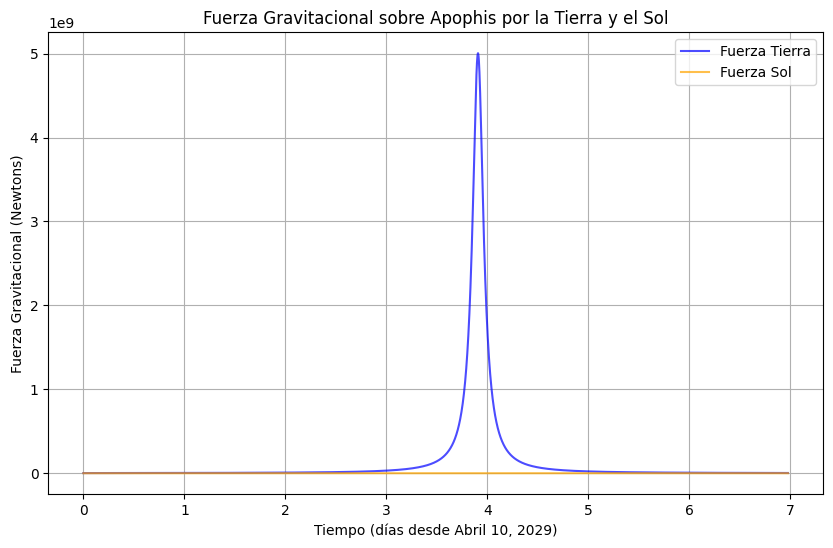

In [145]:
# we compare the gravitational force exerted by the Earth and the Sun on Apophis during the period of the closest approach.

distancias_tierra = np.linalg.norm(rs[1] - rs[2], axis=1) * AU # m
distancias_sol = np.linalg.norm(rs[1] - rs[0], axis=1) * AU # m

fuerza_tierra = G * (masa_apophis * MU) * (masa_tierra * MU) / (distancias_tierra**2)
fuerza_sol = G  * masa_apophis * pc.constantes.M_sun / (distancias_sol**2) 

plt.figure(figsize=(10, 6))
plt.plot(ts * T_canon / (24 * 3600), fuerza_tierra, label='Fuerza Tierra', color='blue', alpha=0.7)
plt.plot(ts * T_canon / (24 * 3600), fuerza_sol, label='Fuerza Sol', color='orange', alpha=0.7)
plt.xlabel('Tiempo (días desde Abril 10, 2029)')
plt.ylabel('Fuerza Gravitacional (Newtons)')
plt.title('Fuerza Gravitacional sobre Apophis por la Tierra y el Sol')
plt.grid("True")
plt.legend()

### <span style="color:pink">Evolución temporal de los elementos orbitales</span>

Para cuantificar la deformación geométrica de la trayectoria inducida por el sobrevuelo terrestre, transformamos los vectores de estado ($\vec{r}$ y $\vec{v}$) arrojados por el integrador numérico a los seis Elementos Orbitales Clásicos de Kepler. Esta conversión asume un marco temporal de dos cuerpos, empleando el parámetro gravitacional canónico del Sol ($\mu = 1$).

Las integrales del movimiento y los vectores fundamentales definen la forma y orientación del plano orbital:

**1. Momento Angular Específico ($\vec{h}$):**
$$\vec{h} = \vec{r} \times \vec{v}$$

**2. Vector de Nodos ($\vec{n}$):**
$$\vec{n} = \hat{k} \times \vec{h}$$

**3. Vector Excentricidad ($\vec{e}$):**
$$\vec{e} = \frac{\vec{v} \times \vec{h}}{\mu} - \frac{\vec{r}}{|\vec{r}|}$$

A partir de la geometría de estos vectores espaciales, se derivan analíticamente los parámetros angulares mediante el producto punto:

* **Inclinación ($I$):**
$$I = \arccos\left(\frac{h_z}{|\vec{h}|}\right)$$

* **Longitud del Nodo Ascendente ($\Omega$):**
$$\Omega = \arccos\left(\frac{n_x}{|\vec{n}|}\right)$$

* **Argumento del Perihelio ($\omega$):**
$$\omega = \arccos\left(\frac{\vec{n} \cdot \vec{e}}{|\vec{n}| |\vec{e}|}\right)$$

* **Anomalía Verdadera ($f$):**
$$f = \arccos\left(\frac{\vec{r} \cdot \vec{e}}{|\vec{r}| |\vec{e}|}\right)$$

In [146]:
# Evolution of orbital elements

h = []
e = []
I = []
omegap = []
Omegap = []
f = []

for i in range(steps):
    rvec_i = rs[1, i]
    vvec_i = vs[1, i]
    r_i = np.linalg.norm(rvec_i)

    # h
    hvec_i = np.cross(rvec_i, vvec_i)
    h_i = np.linalg.norm(hvec_i)
    h.append(h_i)

    # excentricidad
    mu = 1  #approx
    evec_i = np.cross(vvec_i, hvec_i) / mu - rvec_i / np.linalg.norm(rvec_i)
    e_i = np.linalg.norm(evec_i)
    e.append(e_i)

    #vector de nodos    
    nvec_i = np.cross([0, 0, 1], hvec_i)
    n_i = np.linalg.norm(nvec_i)

    #peri
    p = h_i**2 / mu  # p

    # Inclinación
    I_i = np.degrees(np.arccos(hvec_i[2] / h_i))
    I.append(I_i)

    # Argumento del perihelio
    omegap_i = np.arccos(np.dot(nvec_i, evec_i) / (n_i * e_i)) 
    if evec_i[2] < 0:
        omegap_i = 2 * np.pi - omegap_i
    omegap.append(np.degrees(omegap_i))

    # Longitud del nodo ascendente
    Omegap_i = np.arccos((nvec_i@[1,0,0]) / n_i) 
    if nvec_i[1] < 0:
        Omegap_i = 2 * np.pi - Omegap_i
    Omegap.append(np.degrees(Omegap_i))

    # Anomalía verdadera
    f_i = np.arccos(np.dot(rvec_i, evec_i) / (r_i * e_i)) 
    if np.dot(rvec_i, vvec_i)/ r_i < 0:
        f_i = 2 * np.pi - f_i
    f.append(np.degrees(f_i))

Text(0.5, 1.0, 'Longitud del Nodo Ascendente (Ω)')

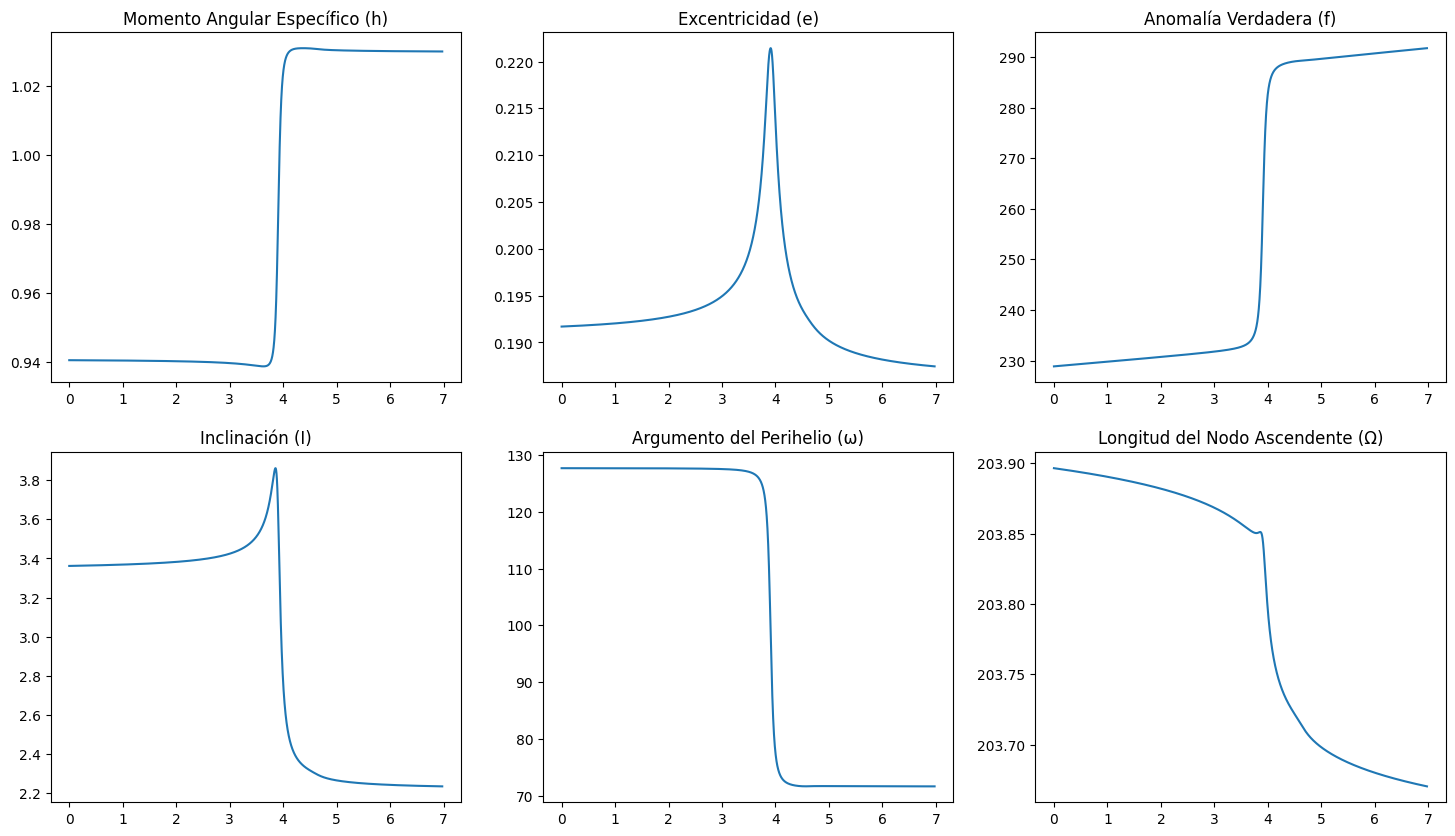

In [147]:
# We graph all orbital elements in a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs[0, 0].plot(ts * T_canon / (24 * 3600), h)
axs[0, 0].set_title('Momento Angular Específico (h)')
axs[0, 1].plot(ts * T_canon / (24 * 3600), e)
axs[0, 1].set_title('Excentricidad (e)')
axs[0, 2].plot(ts * T_canon / (24 * 3600), f)
axs[0, 2].set_title('Anomalía Verdadera (f)')
axs[1, 0].plot(ts * T_canon / (24 * 3600), I)
axs[1, 0].set_title('Inclinación (I)')
axs[1, 1].plot(ts * T_canon / (24 * 3600), omegap)
axs[1, 1].set_title('Argumento del Perihelio (ω)')
axs[1, 2].plot(ts * T_canon / (24 * 3600), Omegap)
axs[1, 2].set_title('Longitud del Nodo Ascendente (Ω)')


### <span style="color:pink">Resultados</span>

Al utilizar el modelo de 16 cuerpos con una resolución temporal de 4000 pasos, se determinó que la máxima aproximación de (99942) Apophis a la Tierra ocurrirá el 13 de abril de 2029 a las 21:46:46 UTC. En este instante, la distancia mínima calculada entre el asteroide y la superficie terrestre es de 31632.74 km, valor que difiere de aquel dado por la NASA (https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=Apophis&view=OPC) por tan solo 0.162km, y 34 segundos, lo que valida completamente nuestra aproximación.

La comparación de las fuerzas gravitacionales indica que, durante el sobrevuelo, la atracción de la Tierra sobrepasa a la atracción solar, y en una escala muy grande. Este cambio en la fuerza dominante se refleja en las gráficas de los elementos orbitales, donde se observan variaciones abruptas para todos los elementos en el momento de paso cercano por la tierra. Estos resultados confirman que el encuentro cercano altera la trayectoria de Apophis de manera medible en comparación con su trayectoria original.

## <span style="color:purple">**Conclusiones**</span>

Este trabajo permitió reconstruir la trayectoria de (99942) Apophis durante su encuentro cercano con la Tierra en 2029 mediante simulaciones numéricas de N-cuerpos. Las conclusiones principales son las siguientes:

Validación del Modelo: La implementación de un modelo de 16 cuerpos con una resolución temporal alta demostró ser suficiente para reproducir con precisión los datos de efemérides oficiales. La distancia mínima calculada (31,633.26 km) muestra una diferencia mínima con respecto a los datos de la NASA, lo que valida la metodología de integración y las condiciones iniciales empleadas.

Dominio Gravitacional: Se confirmó que, durante el sobrevuelo, la esfera de influencia terrestre domina la dinámica del asteroide, superando ampliamente la fuerza gravitacional solar en el punto de máxima aproximación.

Perturbación Orbital: El análisis de los elementos orbitales permitió cuantificar el efecto gravitacional terrestre. Las variaciones abruptas observadas en el momento angular, la excentricidad y la inclinación confirman que el encuentro altera de forma medible y permanente la órbita heliocéntrica del asteroide.

Importancia de la Resolución: Se demostró que la fiabilidad de estos modelos depende críticamente del paso de integración ($\Delta t$). Una resolución temporal alta es indispensable para capturar eventos de alta velocidad, como un sobrevuelo planetario, evitando errores de truncamiento que podrían ocultar la magnitud real de la perturbación.

Trabajo a Futuro

Para futuras iteraciones de este análisis, se identifican las siguientes oportunidades de mejora técnica y metodológica:

* Optimización del código: Implementar una estructura de datos basada en diccionarios para automatizar la consulta de efemérides en JPL Horizons. Esto eliminaría la redundancia de código y permitiría escalar el modelo a un mayor número de asteroides de forma eficiente.

* Implementación de otros análisis: Realizar un análisis de las energías del sistema, y también revisar cómo se comporta este frente a uno aproximación de 2 y de 3 cuerpos.